In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import os
from adjustText import adjust_text
from PIL import Image

In [31]:
wrs = pd.read_csv("wide_receivers.csv")

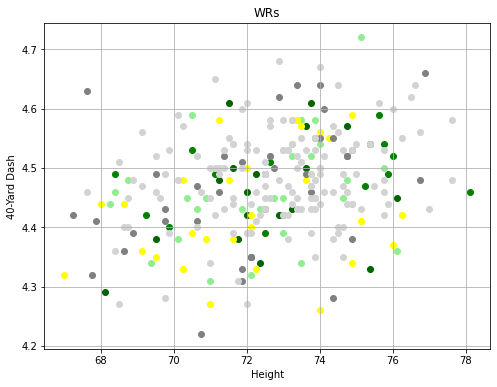

In [32]:
color_mapping = {
    5: "darkgreen",
    4: "green",
    3: "lightgreen",
    2: "yellow",
    1: "gray",
    0: "lightgray"
}

plt.figure(figsize=(8, 6))
for rating, color in color_mapping.items():
    subset = wrs[wrs["PROSPECT RATING"] == rating]
    plt.scatter(subset["Height"], subset["40-Yard Dash"], color=color, label=f"Prospect Rating {rating}")

plt.xlabel("Height")
plt.ylabel("40-Yard Dash")
plt.title("WRs")
plt.grid(True)
plt.show()

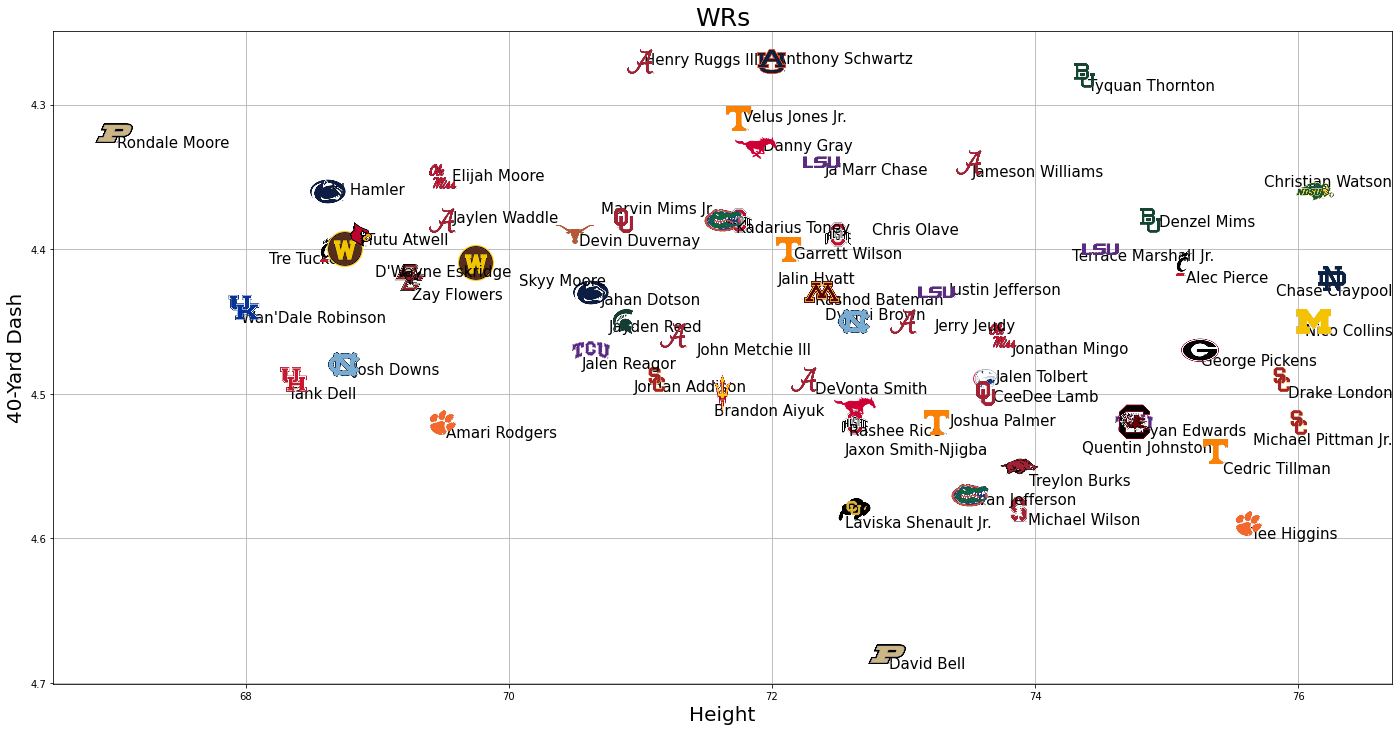

In [28]:
def load_image(image_path):
    img = plt.imread(image_path)

    return OffsetImage(img, zoom=0.25)

wrs = pd.read_csv("wide_receivers.csv")
wrs = wrs[wrs["Drafted Round"].isin([1, 2, 3])]
wrs = wrs[wrs["Draft Class"].isin([2023, 2022, 2021, 2020])]

plt.figure(figsize=(24, 12))
ax = sns.scatterplot(data=wrs, x="Height", y="40-Yard Dash", s=0)

annotations = []
for i in wrs.index:
    annotations.append(ax.text(wrs["Height"][i] + 0.002, wrs["40-Yard Dash"][i], wrs["Player"][i], fontsize=15))
    imagebox = load_image(os.path.abspath(os.path.join(os.getcwd(), os.pardir)) + "/Logos/" + wrs["College"][i] + ".png")
    ab = AnnotationBbox(imagebox, (wrs["Height"][i], wrs["40-Yard Dash"][i]), frameon=False)
    ax.add_artist(ab)

adjust_text(annotations)
plt.gca().invert_yaxis()
plt.xlabel("Height", fontsize=20)
plt.ylabel("40-Yard Dash", fontsize=20)
plt.title("WRs", fontsize=25)
plt.grid(True)
plt.show()